# Movement Mapping — Step 1 of the Real-Time Prosthetic Arm Simulation
## Identifying which NinaPro DB2 movements correspond to the 5 target tasks

---

**Goal:** find, for each of 5 real-world tasks (holding a cup, holding a pen, turning on a
switch, unlocking a door, picking up a box), which NinaPro DB2 Exercise C movement ID
(18-40) is the closest match so the real-time arm simulation can stream that movement's
*actual recorded EMG* through the already-trained Contrastive-SSL CNN, rather than needing
any new data collection.

**Why this notebook exists instead of just looking up a name table:** the original NinaPro
paper (Atzori et al. 2012, *Building the NINAPRO Database*) presents all 52 movement
descriptions only as a photo figure (Fig. 2), not as extractable text confirmed by
directly parsing the paper's PDF. No derivative paper or public code repository found in a
search reproduces the full 23-movement text list either. Rather than guess from an
unverifiable source, this notebook **measures the actual recorded finger-flexion pattern**
of every movement directly from the dataset you already have, and matches each one to the
biomechanical signature of each task (which fingers flex, how much, and in what
combination). This is auditable every assignment below is backed by printed numbers, not
a name lookup.

**Caveat to flag honestly:** this is an *inferred* mapping, not a verified one. If your
NinaPro download included reference photos/videos per stimulus, cross-check the final
picks against those before relying on this for anything beyond a working prototype.

---
## Setup

In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '/Users/kailashjram/Desktop/MSC FINAL PROJECT/Subject Data'
N_CHANNELS = 12   # DB2 EMG channels (used to filter out DB1's 10-channel S1 file)

# Standard CyberGlove II 22-sensor layout (same convention used in Test2/Test3):
# Thumb: rotation, MPJ, IJ, abduction | Index/Ring/Little: MPJ, PIJ, DIJ, abduction
# Middle: MPJ, PIJ, DIJ | Palm arch | Wrist: pitch, yaw
CHANNEL_GROUPS = {
    'ThumbRot': 0, 'ThumbMPJ': 1, 'ThumbIJ': 2, 'ThumbAbd': 3,
    'IndexMPJ': 4, 'IndexPIJ': 5, 'IndexDIJ': 6, 'IndexAbd': 7,
    'MiddleMPJ': 8, 'MiddlePIJ': 9, 'MiddleDIJ': 10,
    'RingMPJ': 12, 'RingPIJ': 13, 'RingDIJ': 14, 'RingAbd': 15,
    'LittleMPJ': 16, 'LittlePIJ': 17, 'LittleDIJ': 18, 'LittleAbd': 19,
    'WristPitch': 20, 'WristYaw': 21,
}
MCP_CHANNELS = {'Thumb': 'ThumbMPJ', 'Index': 'IndexMPJ', 'Middle': 'MiddleMPJ',
                'Ring': 'RingMPJ', 'Little': 'LittleMPJ'}

# Aggregate across multiple subjects for a robust, non-subject-specific signature —
# movement numbering is standardized across subjects in the NinaPro protocol.
SUBJECTS_FOR_MAPPING = [13, 10, 16]
print(f'Using subjects {SUBJECTS_FOR_MAPPING} (E2 files) to build robust movement signatures.')

Using subjects [13, 10, 16] (E2 files) to build robust movement signatures.


---
## Per-movement kinematic signature (averaged across subjects)

In [2]:
# ── Load E2 (Exercise C — grasping/functional movements) glove + stimulus data ──
per_movement_feats = {}   # movement_id -> list of per-subject feature dicts

for subj in SUBJECTS_FOR_MAPPING:
    f = os.path.join(DATA_DIR, f'S{subj}_E2_A1.mat')
    if not os.path.exists(f):
        print(f'  Skipping S{subj}: file not found'); continue
    data = loadmat(f)
    if data['emg'].shape[1] != N_CHANNELS:
        print(f'  Skipping S{subj}: {data["emg"].shape[1]}-channel file (not DB2)'); continue
    stim  = data['restimulus'].flatten()
    glove = data['glove']
    for m in sorted(set(stim.tolist())):
        if m == 0:
            continue
        mask = stim == m
        feat = {name: float(np.mean(glove[mask, ch])) for name, ch in CHANNEL_GROUPS.items()}
        per_movement_feats.setdefault(int(m), []).append(feat)
    print(f'  Loaded S{subj}_E2_A1.mat')

# Average each movement's feature dict across subjects
movement_signature = {}
for m, feats in per_movement_feats.items():
    movement_signature[m] = {name: float(np.mean([f[name] for f in feats])) for name in CHANNEL_GROUPS}

print(f'\nBuilt signatures for {len(movement_signature)} movements '
      f'(averaged over {len(SUBJECTS_FOR_MAPPING)} subjects).')

  Loaded S13_E2_A1.mat


  Loaded S10_E2_A1.mat


  Loaded S16_E2_A1.mat

Built signatures for 23 movements (averaged over 3 subjects).


In [3]:
# ── Display the full signature table ─────────────────────────────────────────
header_cols = ['ThumbMPJ', 'ThumbIJ', 'ThumbAbd', 'IndexMPJ', 'IndexAbd', 'MiddleMPJ', 'RingMPJ', 'LittleMPJ']
print(f'{"mov":>4} ' + ' '.join(f'{c:>10}' for c in header_cols))
for m in sorted(movement_signature):
    sig = movement_signature[m]
    print(f'{m:>4} ' + ' '.join(f'{sig[c]:>10.1f}' for c in header_cols))

 mov   ThumbMPJ    ThumbIJ   ThumbAbd   IndexMPJ   IndexAbd  MiddleMPJ    RingMPJ  LittleMPJ
  18      -13.2        3.2      -14.7       13.8       30.0       38.0       35.3       29.6
  19       -6.5       17.4      -16.8       31.9       55.4       60.4       54.0       40.5
  20      -14.4      -11.0        3.4       31.3       56.0       54.4       49.1       41.0
  21       -3.3       -0.1       -1.0        4.2       35.3       86.6       68.5       54.1
  22      -11.3        9.8      -15.6       17.0       33.6       44.3       37.6       29.1
  23      -16.7        9.6      -13.3       19.3       18.8       18.0       19.4       12.4
  24        2.9       -4.2       -9.3       34.9       44.3       38.0       36.8       29.9
  25       -7.5      -18.8        7.6       26.2       43.2       63.5       54.2       52.1
  26       -1.7       -8.4       -0.1       33.0       50.2       54.0       54.6       55.3
  27       -2.4       21.3       -5.0       35.4       41.3       45.2

**Known data quirk (same one found in Test3):** the `MiddleDIJ` channel (glove channel
10) has a value scale roughly 10x wider than every other channel across every subject
checked -- likely a calibration artifact for that one sensor, not a real degree reading.
It's excluded from all scoring above (only the 5 MCP channels are used), but it will show
up looking huge in `full_signature_degrees` inside the saved JSON below -- that's expected,
not a bug in this notebook.

---
## Scoring each movement against each task's biomechanical signature

In [4]:
# ── Transparent, rule-based scoring — every criterion is a named, printable quantity ──
# Each task is defined by a simple, human-checkable pattern over the 5 MCP channels
# (thumb + 4 fingers), rather than a black-box distance metric.
def mcp(sig):
    return {k: sig[v] for k, v in MCP_CHANNELS.items()}

def score_cup(sig):
    # Cylindrical power grasp: index/middle/ring/little all flex together (low spread),
    # thumb also engaged (opposes around the object).
    m = mcp(sig)
    four_finger = [m['Index'], m['Middle'], m['Ring'], m['Little']]
    uniformity = -np.std(four_finger)              # less spread = more "wrap together"
    magnitude  = np.mean(four_finger)               # need real flexion, not a light touch
    thumb_engaged = max(sig['ThumbIJ'], sig['ThumbMPJ'])
    return uniformity * 0.5 + magnitude * 1.0 + thumb_engaged * 0.5

def score_pen(sig):
    # Tripod precision pinch: thumb+index+middle flex noticeably more than ring+little.
    m = mcp(sig)
    tripod = (m['Index'] + m['Middle']) / 2
    ulnar  = (m['Ring'] + m['Little']) / 2
    thumb_engaged = max(sig['ThumbIJ'], sig['ThumbMPJ'])
    return (tripod - ulnar) * 1.0 + thumb_engaged * 0.5

SWITCH_MAGNITUDE_CAP = 50   # degrees -- above this it's a power hook, not a light button press

def score_switch(sig):
    # Index point/press: index isolated (much LESS flexed than the other three), but the
    # OTHER fingers stay light/moderate too -- a button press is a light touch, not a power
    # hook. Hard-disqualify anything where the other fingers are already deep into a power
    # grip, so this can't collide with score_box's "carry something heavy" pattern.
    m = mcp(sig)
    others = (m['Middle'] + m['Ring'] + m['Little']) / 3
    if others > SWITCH_MAGNITUDE_CAP:
        return -1e6
    return (others - m['Index']) * 1.0

def score_door_key(sig):
    # Lateral/key grip: a light overall grip -- none of the fingers wrap around anything,
    # so overall MCP magnitude should be the LOWEST among the non-trivial movements.
    m = mcp(sig)
    magnitude = np.mean([m['Index'], m['Middle'], m['Ring'], m['Little']])
    return -magnitude   # lower magnitude scores higher for this task

def score_box(sig):
    # Hook/power carry grasp: middle/ring/little flex strongly (carrying a weight on the
    # hooked fingers), index flexes less than them (like a suitcase-handle hook), and overall
    # magnitude is HIGH (unlike the light door/key grip).
    m = mcp(sig)
    hook = (m['Middle'] + m['Ring'] + m['Little']) / 3
    return (hook - m['Index']) * 0.6 + hook * 0.8

TASK_SCORERS = {
    'Holding a cup':        score_cup,
    'Holding a pen':        score_pen,
    'Turning on a switch':  score_switch,
    'Unlocking a door (key/lateral grip)': score_door_key,
    'Picking up a box':     score_box,
}
print('Scoring functions defined for all 5 tasks.')

Scoring functions defined for all 5 tasks.


In [5]:
# ── Rank movements per task and show the top-3 candidates with evidence ──────
movement_catalog = {}
for task, scorer in TASK_SCORERS.items():
    scored = sorted(movement_signature.items(), key=lambda kv: -scorer(kv[1]))
    print(f'\n=== {task} — top 3 candidates ===')
    for m, sig in scored[:3]:
        m_mcp = mcp(sig)
        print(f'  movement {m:>2}  score={scorer(sig):>6.1f}   '
              f'Thumb={m_mcp["Thumb"]:>5.1f} Index={m_mcp["Index"]:>5.1f} '
              f'Middle={m_mcp["Middle"]:>5.1f} Ring={m_mcp["Ring"]:>5.1f} Little={m_mcp["Little"]:>5.1f}')
    best_id, best_sig = scored[0]
    movement_catalog[task] = {
        'movement_id': best_id,
        'evidence_mcp_degrees': mcp(best_sig),
        'full_signature_degrees': best_sig,
        'source_subjects': SUBJECTS_FOR_MAPPING,
        'source_exercise': 'E2',
        'confidence': 'inferred from kinematic pattern, not verified against an official name list',
    }

print('\n' + '='*60)
print('FINAL MOVEMENT CATALOG')
print('='*60)
for task, info in movement_catalog.items():
    print(f'{task:<38} -> movement {info["movement_id"]}')


=== Holding a cup — top 3 candidates ===
  movement 34  score=  53.0   Thumb= -4.5 Index= 41.9 Middle= 56.9 Ring= 50.1 Little= 52.8
  movement 33  score=  51.0   Thumb= -6.7 Index= 38.3 Middle= 50.7 Ring= 46.8 Little= 45.8
  movement 19  score=  49.8   Thumb= -6.5 Index= 31.9 Middle= 60.4 Ring= 54.0 Little= 40.5

=== Holding a pen — top 3 candidates ===
  movement 31  score=  20.3   Thumb= -4.0 Index= 41.1 Middle= 35.8 Ring= 28.2 Little= 24.6
  movement 32  score=  13.6   Thumb= -0.5 Index= 40.4 Middle= 32.9 Ring= 25.0 Little= 23.4
  movement 27  score=  10.2   Thumb= -2.4 Index= 35.4 Middle= 45.2 Ring= 38.2 Little= 43.2

=== Turning on a switch — top 3 candidates ===
  movement 37  score=  24.6   Thumb=  0.2 Index=  5.2 Middle= 42.3 Ring= 28.6 Little= 18.4
  movement 18  score=  20.5   Thumb=-13.2 Index= 13.8 Middle= 38.0 Ring= 35.3 Little= 29.6
  movement 22  score=  20.0   Thumb=-11.3 Index= 17.0 Middle= 44.3 Ring= 37.6 Little= 29.1

=== Unlocking a door (key/lateral grip) — top 3 

---
### Sanity check before trusting this

Two of these scoring functions were designed to be *mutually exclusive* on purpose
(door/key wants low magnitude, box wants high magnitude; switch wants index isolated low,
cup wants index high with the others) — if the top pick for two different tasks turns out
to be the *same* movement ID, that's a sign the patterns aren't as distinct in this data as
assumed and the assignment needs a second look before being used in the app.

In [6]:
# ── Verify no two tasks collapsed onto the same movement ────────────────────
tasks_by_id = {}
for task, info in movement_catalog.items():
    tasks_by_id.setdefault(info['movement_id'], []).append(task)

collisions = {m: tasks for m, tasks in tasks_by_id.items() if len(tasks) > 1}
if collisions:
    print('WARNING — movement ID collisions found, mapping needs manual review:')
    for m, tasks in collisions.items():
        print(f'  movement {m}: {tasks}')
else:
    print('No collisions — every task mapped to a distinct movement ID.')
    for task, info in movement_catalog.items():
        print(f'  {task:<38} -> movement {info["movement_id"]}')

No collisions — every task mapped to a distinct movement ID.
  Holding a cup                          -> movement 34
  Holding a pen                          -> movement 31
  Turning on a switch                    -> movement 37
  Unlocking a door (key/lateral grip)    -> movement 23
  Picking up a box                       -> movement 40


---
## Save the movement catalog

In [7]:
# ── Persist the mapping for the app/database to consume ──────────────────────
catalog_path = 'movement_catalog.json'
with open(catalog_path, 'w') as fh:
    json.dump(movement_catalog, fh, indent=2)
print(f'Saved: {catalog_path}')
print(json.dumps(movement_catalog, indent=2))

Saved: movement_catalog.json
{
  "Holding a cup": {
    "movement_id": 34,
    "evidence_mcp_degrees": {
      "Thumb": -4.490286747614543,
      "Index": 41.85159047444662,
      "Middle": 56.93621063232422,
      "Ring": 50.09488423665365,
      "Little": 52.77949905395508
    },
    "full_signature_degrees": {
      "ThumbRot": 60.249027252197266,
      "ThumbMPJ": -4.490286747614543,
      "ThumbIJ": 10.608883539835611,
      "ThumbAbd": -0.3081693947315216,
      "IndexMPJ": 41.85159047444662,
      "IndexPIJ": 37.31544049580892,
      "IndexDIJ": 8.645392974217733,
      "IndexAbd": 58.414109547932945,
      "MiddleMPJ": 56.93621063232422,
      "MiddlePIJ": -2.5346096754074097,
      "MiddleDIJ": 561.7973429361979,
      "RingMPJ": 50.09488423665365,
      "RingPIJ": -7.362815489371617,
      "RingDIJ": 7.770560264587402,
      "RingAbd": 47.56282170613607,
      "LittleMPJ": 52.77949905395508,
      "LittlePIJ": 6.391281922658284,
      "LittleDIJ": 14.329898198445639,
      "L

---
## EMG signal during each task movement

Everything above is kinematic evidence (glove/finger-angle patterns). This section adds the
other half: what the actual recorded 12-channel forearm surface EMG looks like during each
of the 5 chosen movements — the real muscle signal the CNN sees as input, for the same
segments that produced the finger-angle evidence above. Subject S13 (the one the app's model
was fine-tuned on), one representative continuous occurrence per movement.

In [8]:
# ── Load S13's full E2 raw EMG + stimulus labels (not persisted from the scoring loop) ──
S13_PATH = os.path.join(DATA_DIR, 'S13_E2_A1.mat')
_s13_data = loadmat(S13_PATH)
_s13_emg_raw = _s13_data['emg']
_s13_stim = _s13_data['restimulus'].flatten()

def bandpass_filter(emg, fs=2000, low=20, high=450, order=4):
    from scipy.signal import butter, filtfilt
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, emg, axis=0)

_s13_emg = bandpass_filter(_s13_emg_raw).astype(np.float32)
print(f'S13 E2 loaded: {_s13_emg.shape[0]} samples, {_s13_emg.shape[1]} channels')

S13 E2 loaded: 2545573 samples, 12 channels


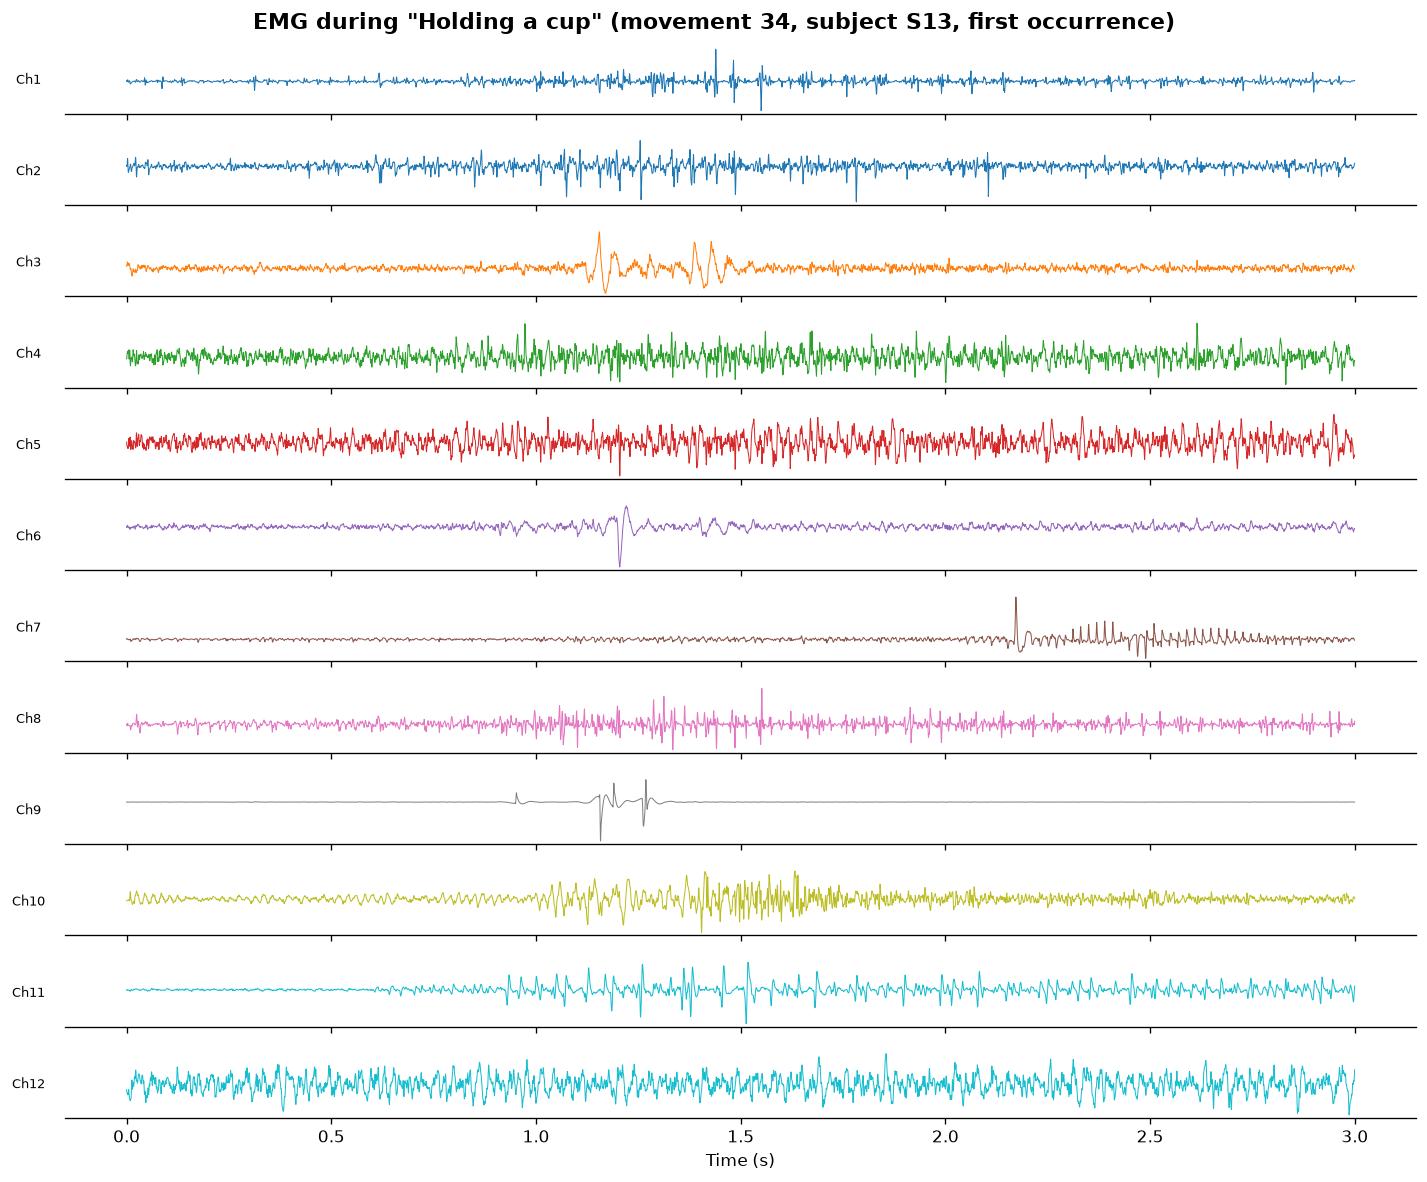

Saved: fig_emg_holding_a_cup.png


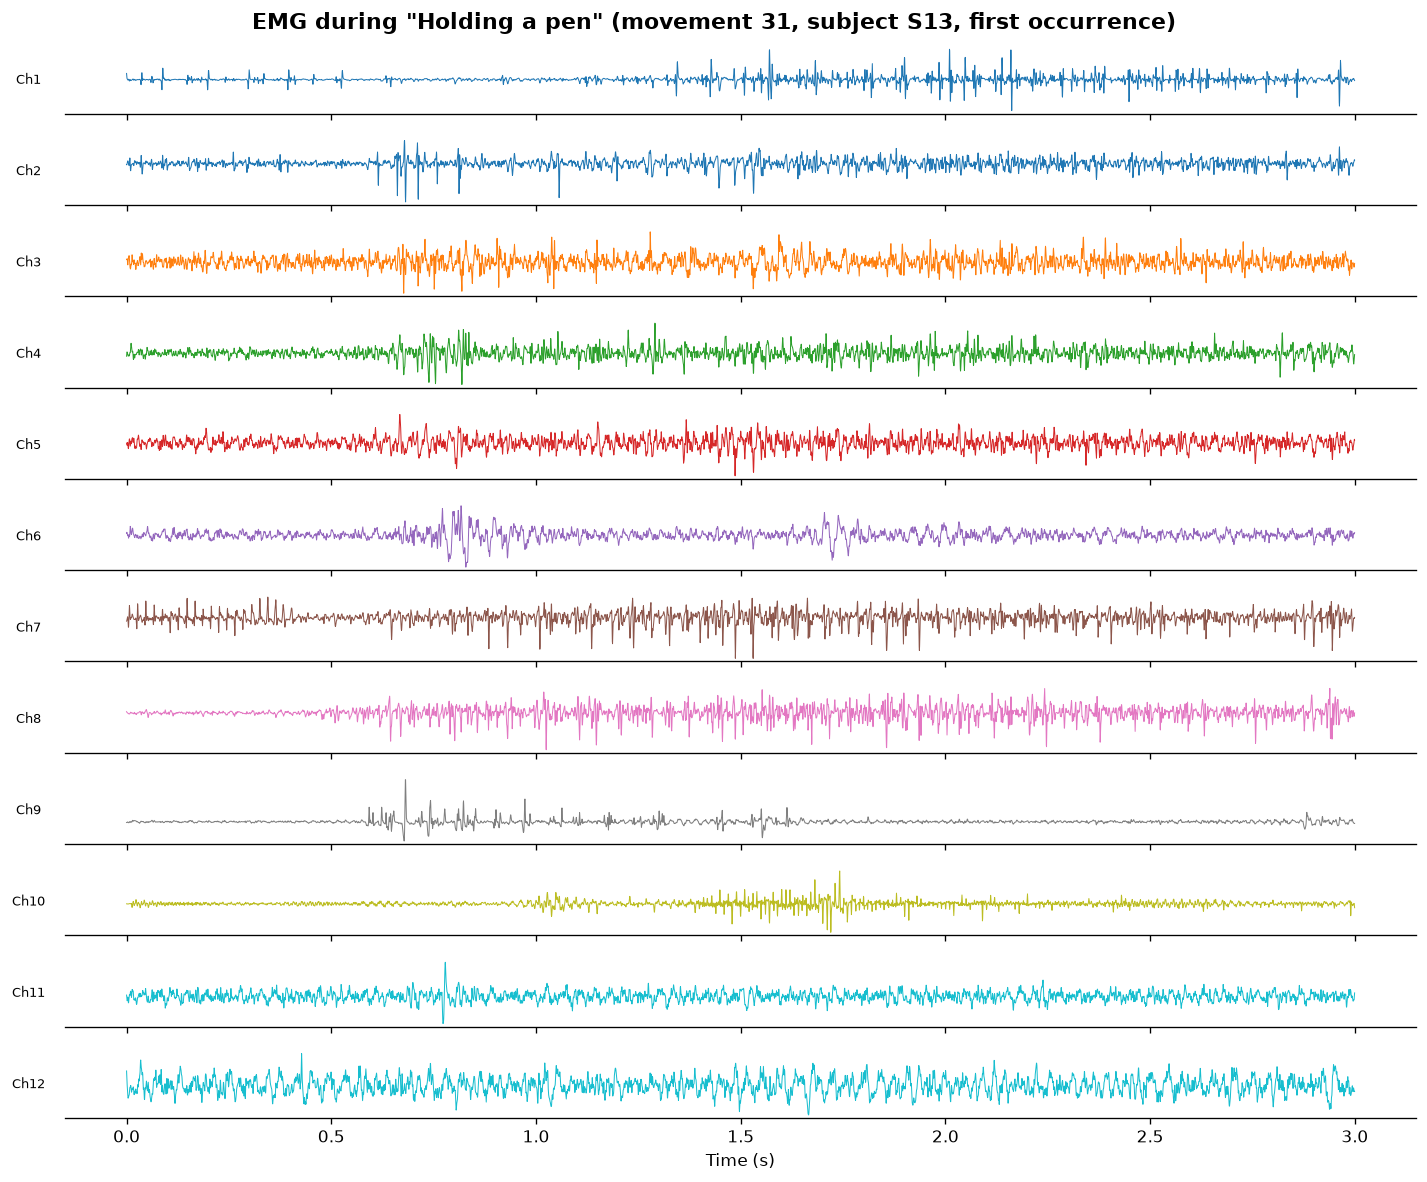

Saved: fig_emg_holding_a_pen.png


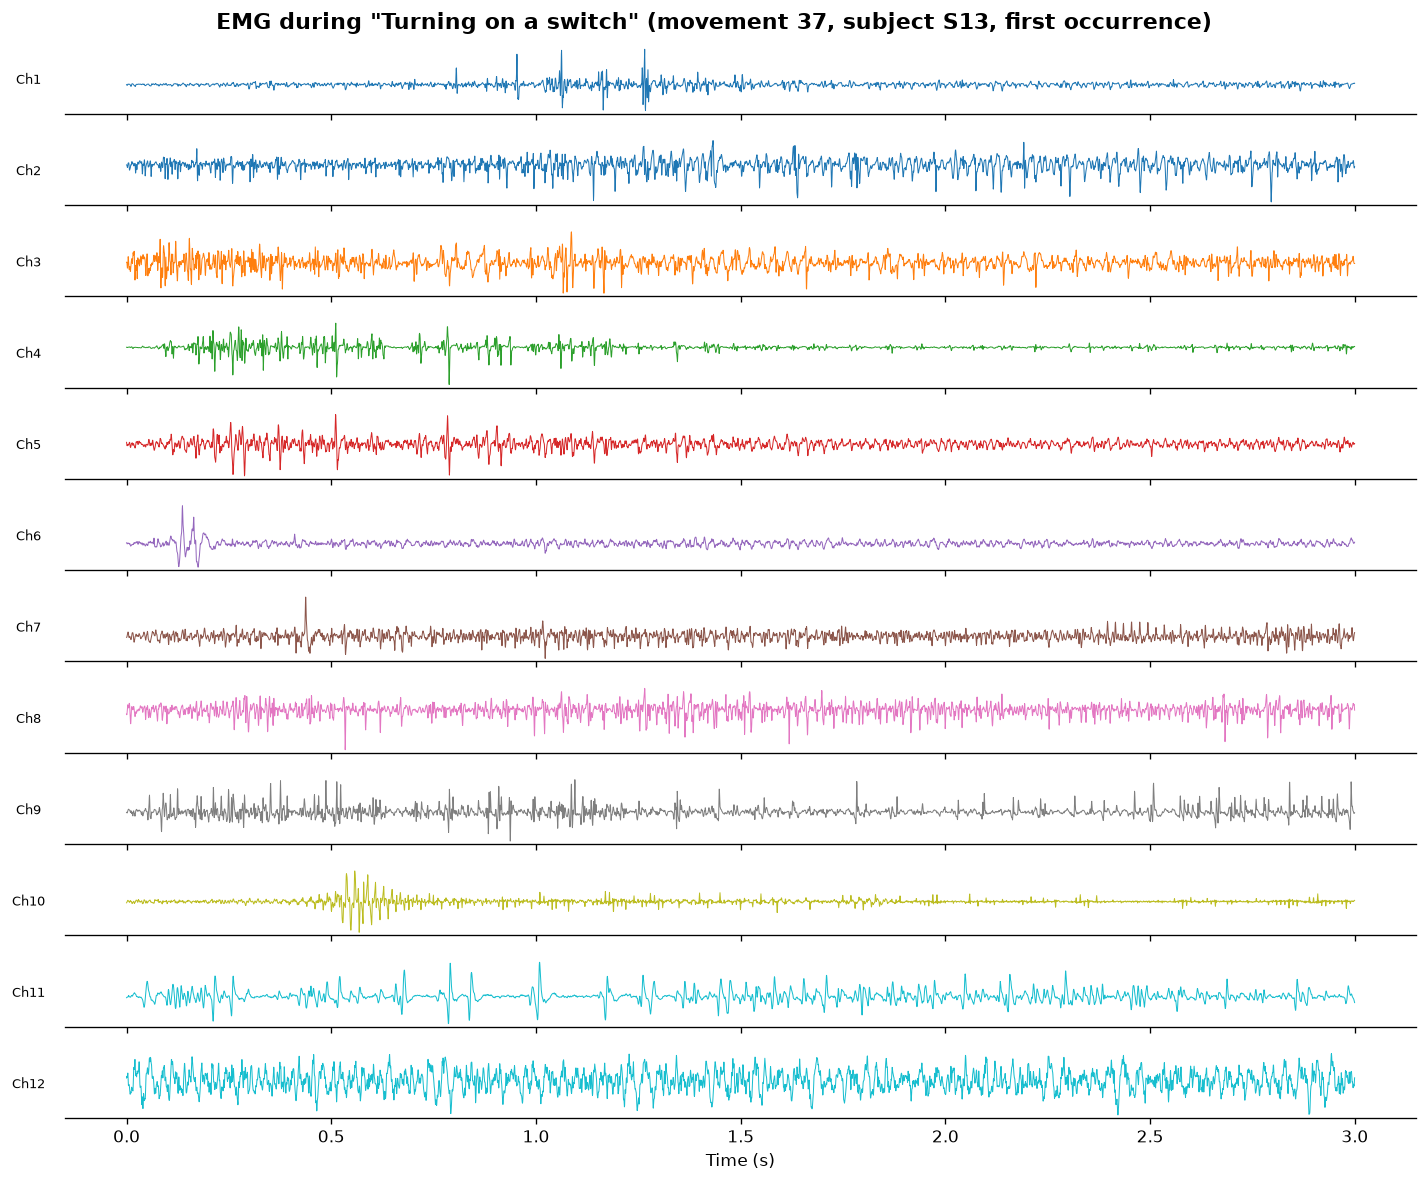

Saved: fig_emg_turning_on_a_switch.png


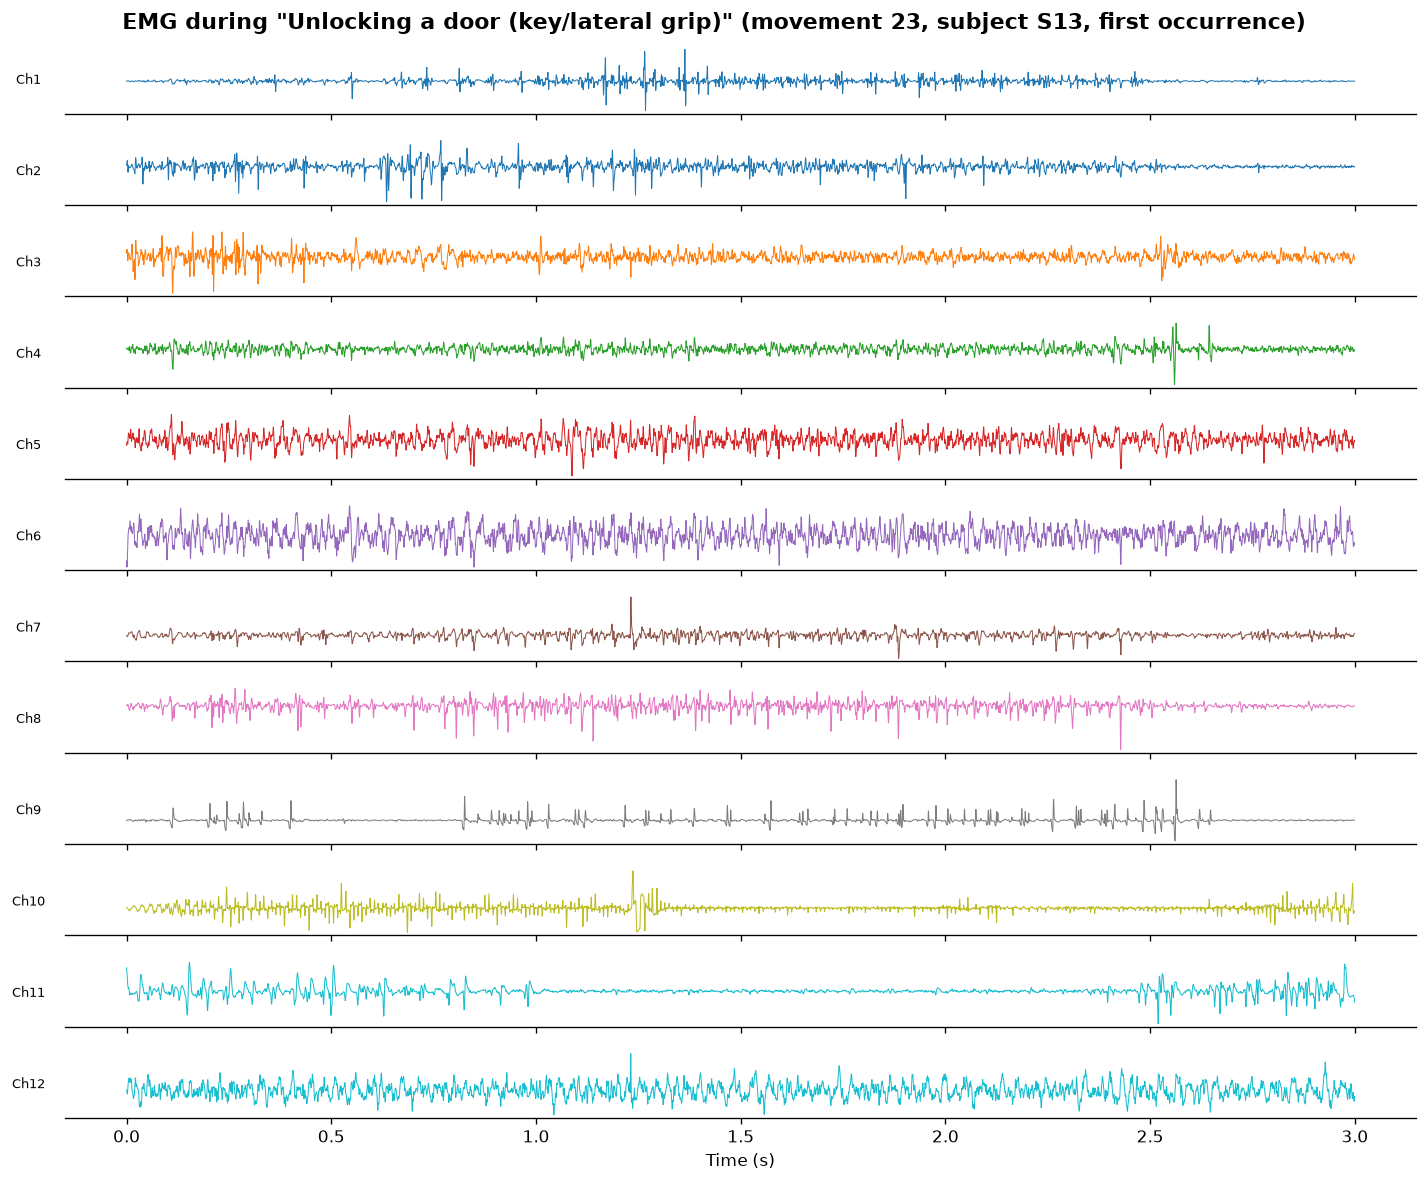

Saved: fig_emg_unlocking_a_door_key_lateral_grip.png


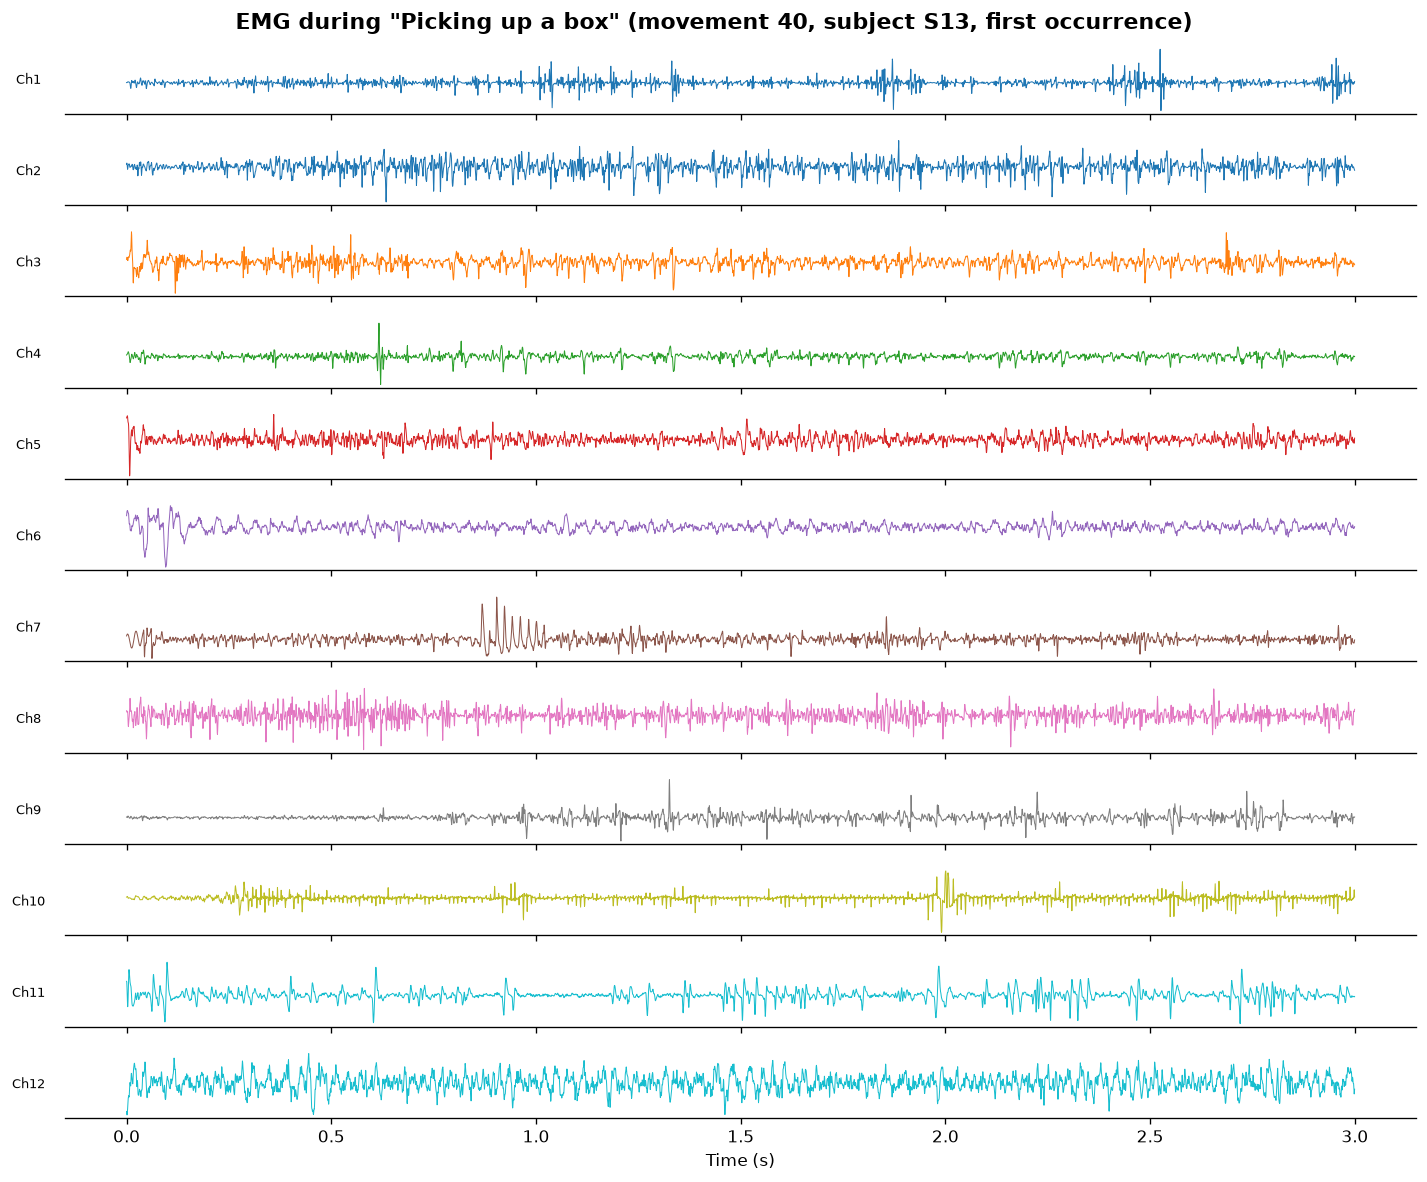

Saved: fig_emg_picking_up_a_box.png


In [9]:
# ── Plot all 12 EMG channels for a representative segment of each chosen movement ──────
FS = 2000
SEGMENT_S = 3.0   # seconds of EMG to show per task
segment_len = int(SEGMENT_S * FS)
colors = plt.cm.tab10(np.linspace(0, 1, 12))

for task, info in movement_catalog.items():
    movement_id = info['movement_id']
    is_movement = (_s13_stim == movement_id)
    onsets = np.where(is_movement & ~np.r_[False, is_movement[:-1]])[0]   # rising edges
    if len(onsets) == 0:
        print(f'No occurrences of movement {movement_id} found for task "{task}" -- skipping')
        continue

    start = onsets[0]
    end = min(start + segment_len, len(_s13_emg))
    segment = _s13_emg[start:end]
    t = np.arange(segment.shape[0]) / FS

    fig, axes = plt.subplots(12, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'EMG during "{task}" (movement {movement_id}, subject S13, first occurrence)',
                 fontsize=13, fontweight='bold')
    for ch in range(12):
        axes[ch].plot(t, segment[:, ch], color=colors[ch], lw=0.6)
        axes[ch].set_ylabel(f'Ch{ch+1}', rotation=0, labelpad=22, va='center', fontsize=8)
        axes[ch].set_yticks([])
        axes[ch].spines[['top', 'right', 'left']].set_visible(False)
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    safe_name = task.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    fig_path = f'fig_emg_{safe_name}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

---
### Notes / next steps

- **This mapping is inferred, not verified.** If your NinaPro download included reference
  stimulus photos/videos (common in the full dataset package), open those for movements
  listed above and confirm the object/task shown actually matches — relabel in
  `movement_catalog.json` directly if not.
- `movement_id` refers to the `restimulus` label in the E2 (`*_E2_A1.mat`) files for any
  DB2 subject — the same ID should represent the same task across subjects, since the
  stimulus presentation protocol is standardized.
- Next step (once this mapping is confirmed): for the real-time simulation, stream the
  EMG windows where `restimulus == movement_id` (for the chosen patient/subject) through
  the already-trained Contrastive-SSL CNN window-by-window, exactly like the existing
  `process_file_raw` / `EMGWindowDataset` pipeline in Test3, and feed the predicted 22
  joint angles to the 3D rig's bone rotations frame-by-frame.